In [1]:
%pip install tensorflow

import pandas as pd
import numpy as np
from io import StringIO
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. SCADA Dosyasını Okuma
scada_yolu = "Turbine_Data_Kelmarsh_1_2021-01-01_-_2022-01-01_228.csv"
with open(scada_yolu, encoding='utf-8') as f:
    lines = [line.rstrip('\n') for line in f]
header_line = next(line for line in lines if line.lstrip().startswith('# Date and time'))
clean_lines = [header_line.lstrip('#').strip()] + [
    line.strip() for line in lines if line.strip() and not line.lstrip().startswith('#')
]
df = pd.read_csv(StringIO('\n'.join(clean_lines)), parse_dates=['Date and time'])
df.set_index('Date and time', inplace=True)
df.sort_index(inplace=True)

# 2. Status Olay Günlüğünü Okuma
status_yolu = "Status_Kelmarsh_1_2021-01-01_-_2022-01-01_228.csv"
status_df = pd.read_csv(status_yolu, comment='#')
stops = status_df[status_df['Status'] == 'Stop'].copy()
stops['Timestamp start'] = pd.to_datetime(stops['Timestamp start'])
stops['Timestamp end'] = pd.to_datetime(stops['Timestamp end'], errors='coerce')

print("Ham SCADA Satır Sayısı:", df.shape[0])
print("Filtrelenecek Durma (Stop) Olay Sayısı:", stops.shape[0])


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Ham SCADA Satır Sayısı: 52560
Filtrelenecek Durma (Stop) Olay Sayısı: 132


In [2]:
temiz_scada = df.copy()
for _, row in stops.iterrows():
    start = row['Timestamp start']
    end = row['Timestamp end']
    if pd.notna(end):
        mask = ~((temiz_scada.index >= start) & (temiz_scada.index <= end))
    else:
        mask = ~(temiz_scada.index == start)
    temiz_scada = temiz_scada[mask]

features = ['Wind speed (m/s)', 'Wind direction (°)', 'Power (kW)']
data = temiz_scada[features].dropna()
data = data[data['Power (kW)'] >= 0]

print("Temizlenmiş Aktif Üretim Verisi Satır Sayısı:", data.shape[0])

Temizlenmiş Aktif Üretim Verisi Satır Sayısı: 44496


In [3]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

def create_dataset(dataset, time_steps=24):
    X, y = [], []
    for i in range(len(dataset) - time_steps):
        X.append(dataset[i:(i + time_steps), :])
        y.append(dataset[i + time_steps, 2])
    return np.array(X), np.array(y)

time_steps = 24  # 4 saatlik geçmiş (10 dakikalık 24 adım)
X, y = create_dataset(scaled_data, time_steps)

train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print("Eğitim seti boyutu (Örnek, Zaman Adımı, Özellik):", X_train.shape)
print("Test seti boyutu:", X_test.shape)

Eğitim seti boyutu (Örnek, Zaman Adımı, Özellik): (35577, 24, 3)
Test seti boyutu: (8895, 24, 3)


In [4]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    shuffle=False
)

Epoch 1/15


C:\Users\yucel\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


501/501 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - loss: 0.0167 - val_loss: 0.0120
Epoch 2/15
501/501 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - loss: 0.0101 - val_loss: 0.0094
Epoch 3/15
501/501 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - loss: 0.0079 - val_loss: 0.0079
Epoch 4/15
501/501 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - loss: 0.0070 - val_loss: 0.0070
Epoch 5/15
501/501 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - loss: 0.0065 - val_loss: 0.0065
Epoch 6/15
501/501 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - loss: 0.0062 - val_loss: 0.0065
Epoch 7/15
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 18ms/step - loss: 0.0060 - val_loss: 0.0064
Epoch 8/15
501/501 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - loss: 0.0060 - val_loss: 0.0065
Epoch 9/15
501/501 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - loss: 0.0059 - val_loss: 0.0065
Epoch 10/15
501/501 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - loss: 0.0058 - val_loss: 0.0065
Epoch 11/15
501/501 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - loss: 0.0058 - val_loss: 0.0066
Epoch 12/15
501/501 ━━━━━━━━━━━━━━━━━━━━ 

278/278 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

--- Model Test Performansı ---
Test MAE : 132.35 kW
Test RMSE: 179.26 kW


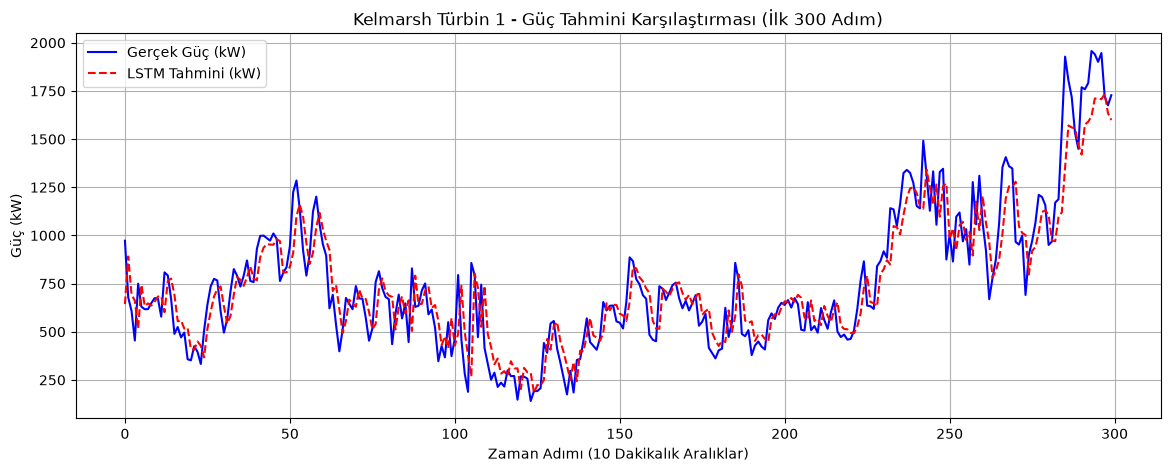

In [5]:
y_pred_scaled = model.predict(X_test)

dummy_pred = np.zeros((len(y_pred_scaled), 3))
dummy_pred[:, 2] = y_pred_scaled[:, 0]
y_pred = scaler.inverse_transform(dummy_pred)[:, 2]

dummy_test = np.zeros((len(y_test), 3))
dummy_test[:, 2] = y_test
y_true = scaler.inverse_transform(dummy_test)[:, 2]

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print(f"\n--- Model Test Performansı ---")
print(f"Test MAE : {mae:.2f} kW")
print(f"Test RMSE: {rmse:.2f} kW")

plt.figure(figsize=(14, 5))
plt.plot(y_true[:300], label='Gerçek Güç (kW)', color='blue')
plt.plot(y_pred[:300], label='LSTM Tahmini (kW)', color='red', linestyle='--')
plt.title('Kelmarsh Türbin 1 - Güç Tahmini Karşılaştırması (İlk 300 Adım)')
plt.xlabel('Zaman Adımı (10 Dakikalık Aralıklar)')
plt.ylabel('Güç (kW)')
plt.legend()
plt.grid(True)
plt.savefig('tahmin_grafigi.png', dpi=300, bbox_inches='tight')
plt.show()